In [2]:
import pandas as pd
import numpy as np

In [4]:
# Chargement des données
df = pd.read_csv('/home/jovyan/data/raw/mimic3d.csv')

In [5]:
# Dimensions
print(f"Lignes    : {df.shape[0]:,}")
print(f"Colonnes  : {df.shape[1]}")
print(f"\nColonnes disponibles :")
print(df.columns.tolist())

Lignes    : 58,976
Colonnes  : 28

Colonnes disponibles :
['hadm_id', 'gender', 'age', 'LOSdays', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'NumCallouts', 'NumDiagnosis', 'NumProcs', 'AdmitProcedure', 'NumCPTevents', 'NumInput', 'NumLabs', 'NumMicroLabs', 'NumNotes', 'NumOutput', 'NumRx', 'NumProcEvents', 'NumTransfers', 'NumChartEvents', 'ExpiredHospital', 'TotalNumInteract', 'LOSgroupNum']


In [7]:
# Aperçu des premières lignes
df.head()

,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,...,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
0,100001,F,35,6.17,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,...,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89,1
1,100003,M,59,4.04,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,...,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71,1
2,100006,F,48,12.04,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,...,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00,3
3,100007,F,73,7.29,EMERGENCY,EMERGENCY ROOM ADMIT,BOWEL OBSTRUCTION,Private,JEWISH,MARRIED,...,0.69,0.17,9.05,11.52,0.00,0.96,526.06,0,603.05,1
4,100009,M,60,4.88,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,CORONARY ARTERY DISEASE,Private,CATHOLIC,MARRIED,...,0.61,0.34,16.19,25.00,2.87,2.05,554.92,0,679.84,1


In [9]:
# Types de chaque colonne
df.dtypes

hadm_id               int64
gender               object
age                   int64
LOSdays             float64
admit_type           object
admit_location       object
AdmitDiagnosis       object
insurance            object
religion             object
marital_status       object
ethnicity            object
NumCallouts         float64
NumDiagnosis        float64
NumProcs            float64
AdmitProcedure       object
NumCPTevents        float64
NumInput            float64
NumLabs             float64
NumMicroLabs        float64
NumNotes            float64
NumOutput           float64
NumRx               float64
NumProcEvents       float64
NumTransfers        float64
NumChartEvents      float64
ExpiredHospital       int64
TotalNumInteract    float64
LOSgroupNum           int64
dtype: object

In [10]:
# Statistiques de base
df.describe()

,hadm_id,age,LOSdays,NumCallouts,NumDiagnosis,NumProcs,NumCPTevents,NumInput,NumLabs,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
count,58976.000000,58976.000000,58976.000000,58976.000000,58976.00000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000,58976.000000
mean,149970.809584,53.005884,10.114955,0.099374,2.67596,0.785599,1.074118,30.379017,46.421124,1.219913,6.464789,7.111594,9.593702,0.691903,1.093313,528.505172,0.099261,636.115579,1.360248
std,28883.095213,26.028120,12.456231,0.163437,8.26559,3.558090,2.027148,62.430163,76.061561,4.236693,106.709903,7.551822,12.601338,2.117615,3.169441,640.250063,0.299014,783.938087,1.130337
min,100001.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,124952.750000,43.000000,3.710000,0.000000,0.82000,0.210000,0.000000,4.850000,26.980000,0.160000,0.140000,1.750000,4.330000,0.000000,0.380000,207.410000,0.000000,267.407500,0.000000
50%,149989.500000,59.000000,6.460000,0.000000,1.41000,0.420000,0.970000,13.990000,38.520000,0.510000,0.330000,5.310000,8.370000,0.000000,0.650000,417.875000,0.000000,497.335000,1.000000
75%,174966.500000,73.000000,11.790000,0.160000,2.40000,0.710000,1.560000,34.360000,50.860000,1.350000,0.770000,10.490000,12.270000,0.880000,1.060000,700.302500,0.000000,811.382500,2.000000
max,199999.000000,89.000000,294.630000,4.760000,450.00000,275.000000,225.000000,6825.000000,5175.000000,375.000000,7500.000000,375.000000,750.000000,100.000000,125.000000,49325.000000,1.000000,68600.000000,3.000000


In [15]:
# Compter les valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Afficher seulement les colonnes qui ont des manquants
result = pd.DataFrame({
    'valeurs_manquantes': missing,
    'pourcentage': missing_pct
})

result = result[result['valeurs_manquantes'] > 0].sort_values('pourcentage', ascending=False)

print(f"Colonnes avec valeurs manquantes : {len(result)}/{df.shape[1]}")
print("==" * 50)
print(result)

Colonnes avec valeurs manquantes : 3/28
                valeurs_manquantes  pourcentage
marital_status               10128        17.17
religion                       458         0.78
AdmitDiagnosis                  25         0.04


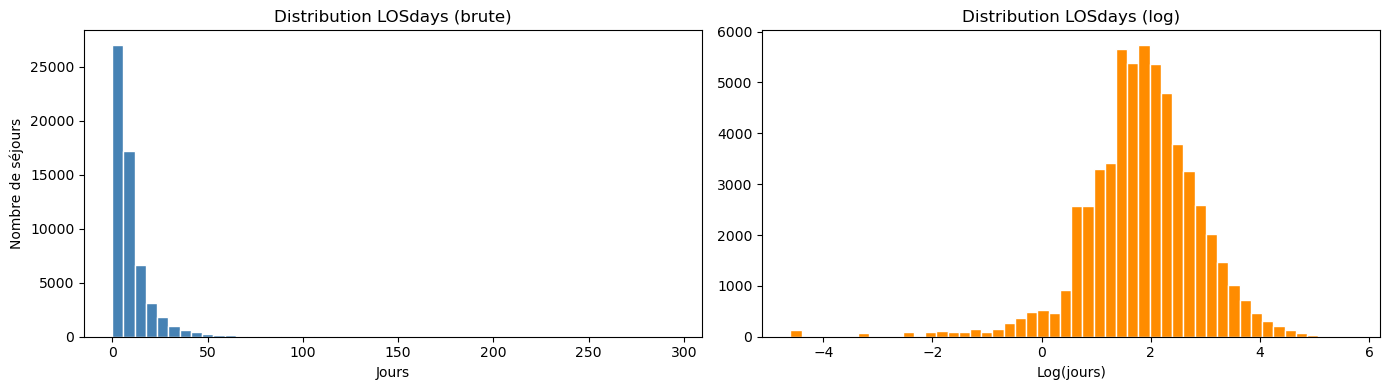

count    58976.00
mean        10.11
std         12.46
min          0.00
25%          3.71
50%          6.46
75%         11.79
max        294.63
Name: LOSdays, dtype: float64

Séjours > 30 jours : 3060 (5.2%)
Séjours > 7 jours  : 27088 (45.9%)


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution brute
axes[0].hist(df['LOSdays'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution LOSdays (brute)')
axes[0].set_xlabel('Jours')
axes[0].set_ylabel('Nombre de séjours')

# Distribution log (pour mieux voir)
axes[1].hist(df['LOSdays'].apply(lambda x: x if x > 0 else 0.01).apply('log'), 
             bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution LOSdays (log)')
axes[1].set_xlabel('Log(jours)')

plt.tight_layout()
plt.savefig('/home/jovyan/notebooks/los_distribution.png')
plt.show()

# Statistiques clés
print(df['LOSdays'].describe().round(2))
print(f"\nSéjours > 30 jours : {(df['LOSdays'] > 30).sum()} ({(df['LOSdays'] > 30).mean()*100:.1f}%)")
print(f"Séjours > 7 jours  : {(df['LOSdays'] > 7).sum()} ({(df['LOSdays'] > 7).mean()*100:.1f}%)")

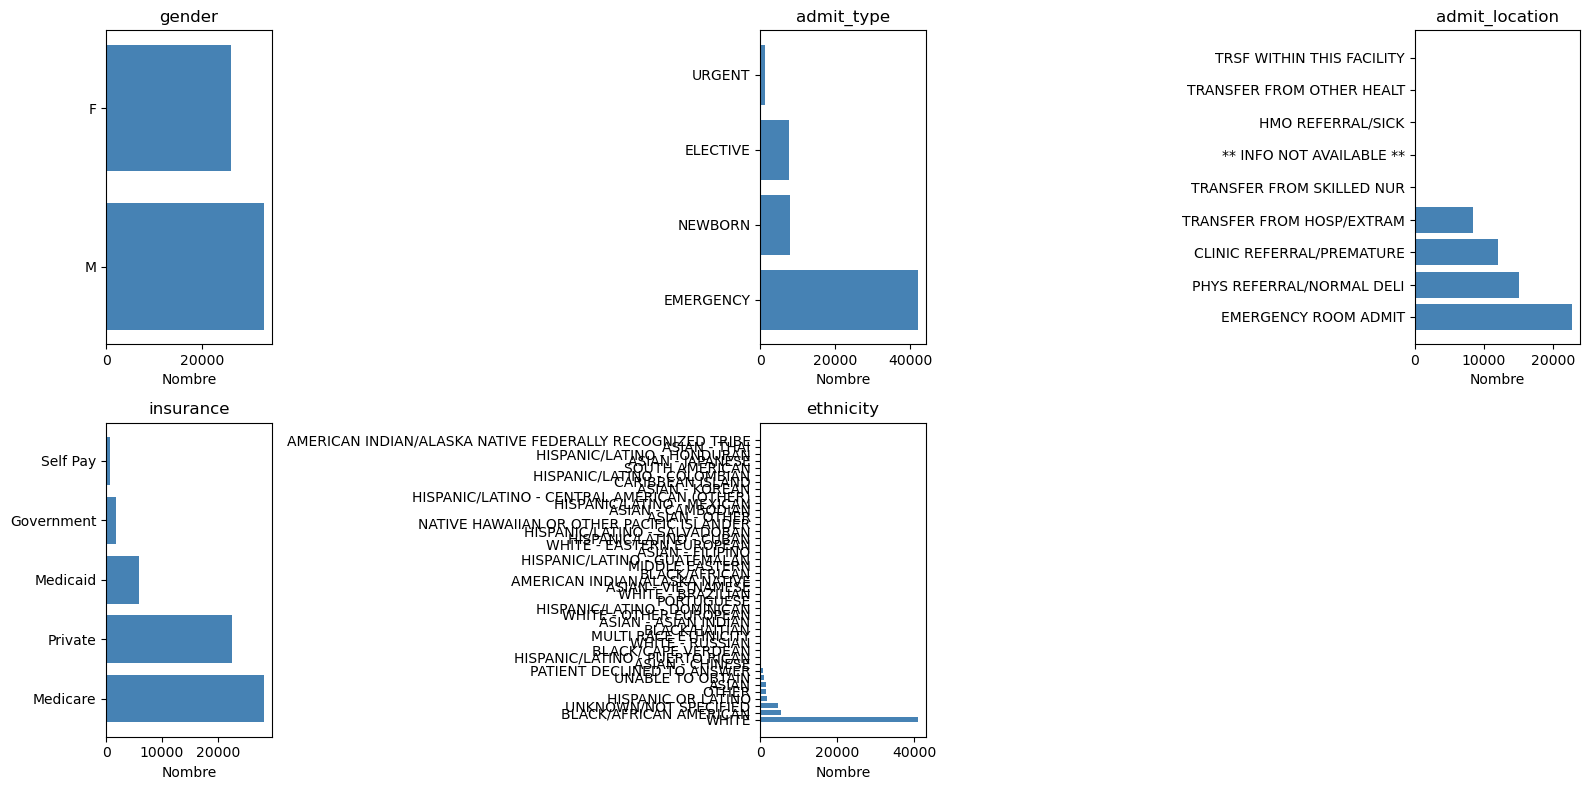

In [17]:
# Étape 7 — Distribution des variables catégorielles
cat_cols = ['gender', 'admit_type', 'admit_location', 'insurance', 'ethnicity']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Nombre')

# Cacher le 6ème graphique (vide)
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('/home/jovyan/notebooks/categorical_distributions.png')
plt.show()

In [19]:
# Étape 8 — Corrélation avec LOSdays
# On veut savoir quelles variables numériques influencent le plus la durée de séjour.

# Sélectionner uniquement les colonnes numériques
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculer la corrélation avec LOSdays
correlations = df[num_cols].corr()['LOSdays'].drop('LOSdays')
correlations = correlations.abs().sort_values(ascending=False)

print("Corrélations avec LOSdays :")
print(correlations.round(3))

Corrélations avec LOSdays :
LOSgroupNum         0.666
NumCallouts         0.206
NumRx               0.169
NumTransfers        0.168
NumDiagnosis        0.156
NumProcEvents       0.100
NumLabs             0.098
NumProcs            0.088
NumInput            0.065
NumNotes            0.046
NumCPTevents        0.045
NumChartEvents      0.033
age                 0.033
NumMicroLabs        0.031
NumOutput           0.018
TotalNumInteract    0.010
hadm_id             0.000
ExpiredHospital     0.000
Name: LOSdays, dtype: float64


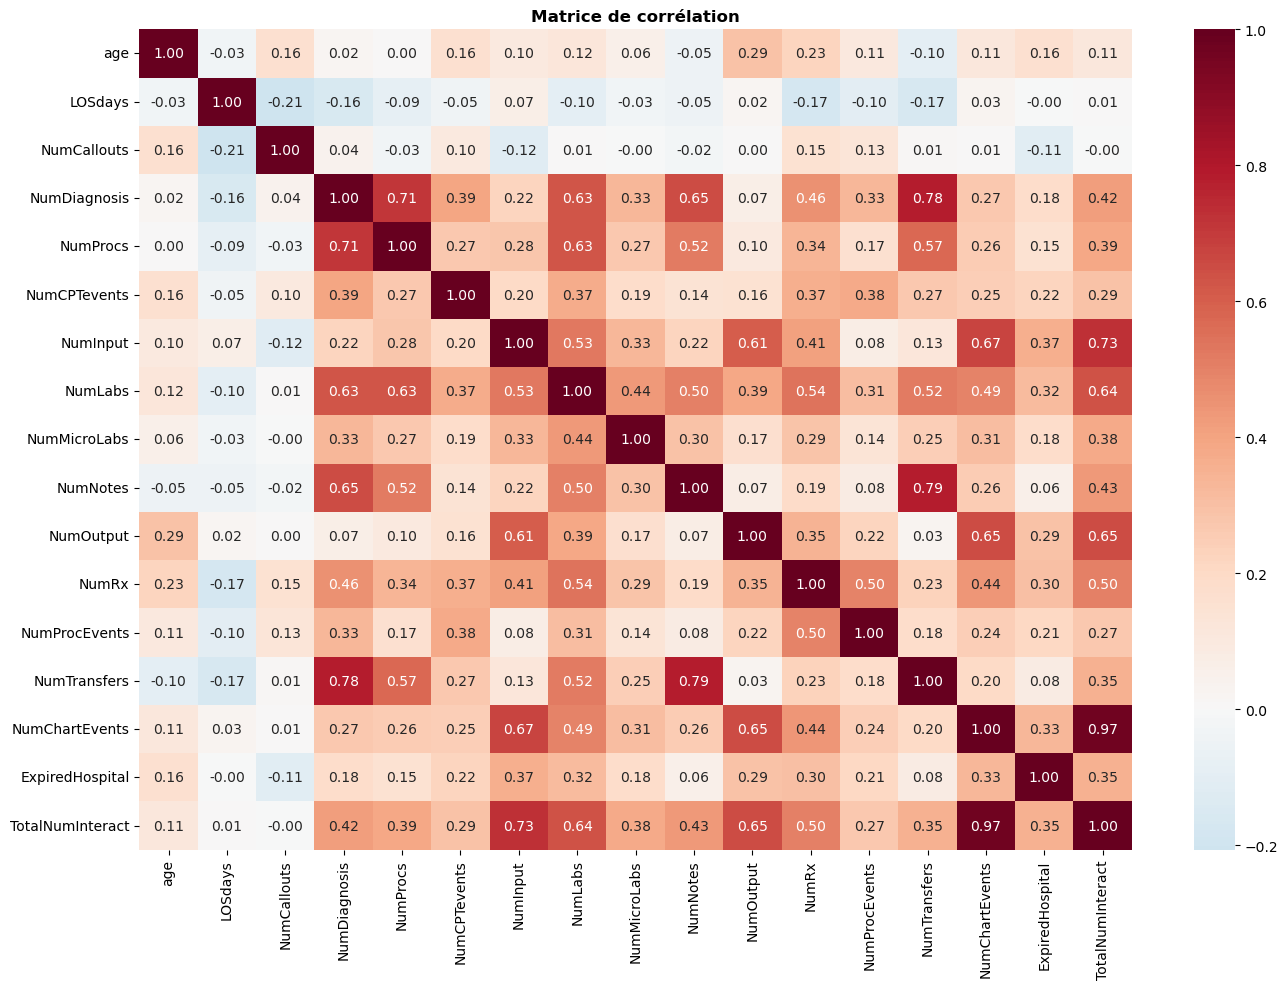

In [20]:
# Étape 9 — Matrice de corrélation visuelle
import seaborn as sns

# Exclure LOSgroupNum et hadm_id
cols_for_corr = [c for c in num_cols if c not in ['LOSgroupNum', 'hadm_id']]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    df[cols_for_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax
)
ax.set_title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jovyan/notebooks/correlation_matrix.png')
plt.show()

In [21]:
# Étape 10 — Synthèse de l'exploration
print("=" * 50)
print("SYNTHÈSE EXPLORATION MIMIC3d")
print("=" * 50)

print(f"""
DATASET
  Séjours      : {df.shape[0]:,}
  Variables    : {df.shape[1]}

QUALITÉ
  Manquants    : 3 colonnes (max 17% sur marital_status)
  Outliers     : LOSdays max = {df['LOSdays'].max()} jours

VARIABLE CIBLE (LOSdays)
  Moyenne      : {df['LOSdays'].mean():.1f} jours
  Médiane      : {df['LOSdays'].median():.1f} jours
  > 30 jours   : {(df['LOSdays'] > 30).mean()*100:.1f}%

ACTIONS JOUR 2
  1. Exclure LOSgroupNum (data leakage)
  2. Exclure TotalNumInteract (redondant avec NumChartEvents)
  3. Imputer marital_status, religion, AdmitDiagnosis
  4. Regrouper les ethnies
  5. Encoder les variables catégorielles
""")

SYNTHÈSE EXPLORATION MIMIC3d

DATASET
  Séjours      : 58,976
  Variables    : 28

QUALITÉ
  Manquants    : 3 colonnes (max 17% sur marital_status)
  Outliers     : LOSdays max = 294.63 jours

VARIABLE CIBLE (LOSdays)
  Moyenne      : 10.1 jours
  Médiane      : 6.5 jours
  > 30 jours   : 5.2%

ACTIONS JOUR 2
  1. Exclure LOSgroupNum (data leakage)
  2. Exclure TotalNumInteract (redondant avec NumChartEvents)
  3. Imputer marital_status, religion, AdmitDiagnosis
  4. Regrouper les ethnies
  5. Encoder les variables catégorielles

